# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print('Cantidad de valores nulos-Users')
print(users.isna().sum())
print() #Salto de linea
print('Proporción de valores nulos-Users')
print(users.isna().mean())

Cantidad de valores nulos-Users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos-Users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print('Cantidad de valores nulos-Usage')
print(usage.isna().sum())
print() #Salto de linea
print('Proporción de valores nulos-Usage')
print(usage.isna().mean())

Cantidad de valores nulos-Usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos-Usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En USERS:
city tiene 11.7% de nulos, se ignoraran porque sin datos adicionales no hay forma de imputar lógicamente.
churn_date con 88.35% de nulos, se identifica que NaN = usuario activo. Se reinterpreta como usuario activo.

Para USAGE::
date con 0.125% nulos, se ignoran en el analisis.
duration y length tienen 55,19 y 44,74% de nulos. Son MAR, los nulos son esperados según el tipo de registro. Los ignoro porque no puedo imputar valores porque esta es la respuesta logica.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id','age']].describe() #Se filtra el dataset en base a las columnas numericas

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Muestra valores desde 10000 hasta 13999 para un total de 4000 registros
- La columna `age` muestra datos desde -999 hasta 79. Este dato inicial corresponde a un sentinel que esta afectando la desviacion estandar y haciendo que la media no sea representativa y en su lugar sea mejor usar la mediana para describir la edad tipica de los usuarios.

In [13]:
# explorar columnas numéricas de usage
usage[['id','user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`contienen 40000 registros 
- Las columnas `duration` y `length` tienen 17924 y 22104 registros respectivamente ambos con un minimo de 0. Los valores maximos corresponden a 120 y 1490, estos valores podrian ser posibles outliers, especialmente `duration` ya que una llamada de 120 minutos suena poco realista.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user: #agregamos un bucle para realizar el análisis
    print(col)
    print(users[col].value_counts()) # Usamos Value_Counts porque muestra cuántas veces aparece cada valor, incluyendo sentinels como
    print() #Salto de linea

print('Distribucion porcentual de planes')
print('Plan Basico', 2595/4000*100)
print('Plan Premium', 1405/4000*100)

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64

Distribucion porcentual de planes
Plan Basico 64.875
Plan Premium 35.125


- La columna `city` contiene 7 tipos de registro y uno de ellos corresponde a sentinel `?`, este contiene 96 registros.
- La columna `plan` contiene solo dos registros basico y premium, siendo el plan basico predominante con 64.875%.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene solo dos registros text y calls y es importante mencionar que los nulos en `duration` corresponden a registros de tipo **text**, y los nulos en `length` a registros de tipo **call**.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En las columnas de `age` (-999) y en `City` (?) se encontraron valores invalidos.  
- ¿Qué acción tomarías?
Es necesario asignarles un valor logico y representativo, como la mediana en `age` y no asignado/determinado en `city`. Deben imputarse por el valor correcto o reemplazarse por NaN.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` se observan cuatro años diferentes: 2022, 2023, 2024 y 2026. Sin embargo, los datos fueron capturados hasta 2024; no debería haber datos de 2026. Esto indica que los registros de 2026 están erróneos. Estos registros podrian ser marcados como nulos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date`, solo se encuentran registros correspondientes al ano 2024. Sin embargo hay 50 registros nulos que deberian corregirse en el analisis. Considerando que no hay columnas adicionales que permitan imputar la fecha y los demás datos del registro (tipo, duración, usuario) siguen siendo útiles, además de que los nulos solo representan el 0.125% del total estos nulos pueden dejarse como NA.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- Si aparecen años imposibles en la columna `reg_date`, los datos de 2026, ya que los datos fueron tomados hasta el año 2024, no años posteriores. 
- ¿Qué harías con ellas?
- Estos datos  de 2026 los definiría como NA, ya que no hay otras columnas que indiquen el año real de  estos datos y las demás columnas en esos registros de 2026 aún son útiles para el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median() #Se calcula la mediana de age
users['age'] = users['age'].replace(-999, age_mediana) #Se reemplaza el sentinel -999 por la mediana

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA) #Se reelp

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print('Valores nulos en Duration',usage['duration'].isna().sum())
print() #Salto de linea
print('Call vs Text en type')
print(usage['type'].value_counts())

Valores nulos en Duration 22076

Call vs Text en type
text    22092
call    17908
Name: type, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print('Valores nulos en Length',usage['length'].isna().sum())
print() #Salto de linea
print('Call vs Text en type')
print(usage['type'].value_counts())

Valores nulos en Length 17896

Call vs Text en type
text    22092
call    17908
Name: type, dtype: int64


La proporción de valores nulos en `duration` y `length`corresponde casi idénticamente a la cantidad de valores en la columna `type`, infiriendo que la columna `duration` representa el tiempo de duración de la llamada, por lo que los valores correspondientes a texto están vacíos, y la columna `length` representa la longitud del texto, por lo que los valores correspondientes a llamada están vacíos. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({'is_text':'sum', 'is_call':'sum','duration':'sum'}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left') #Se combina la tabla por medio de user_id con left join

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [29]:
# Distribución porcentual del tipo de plan
print(users['plan'].value_counts(normalize=True)) #Se coloca el parámetro normalize para obtener porcentaje

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

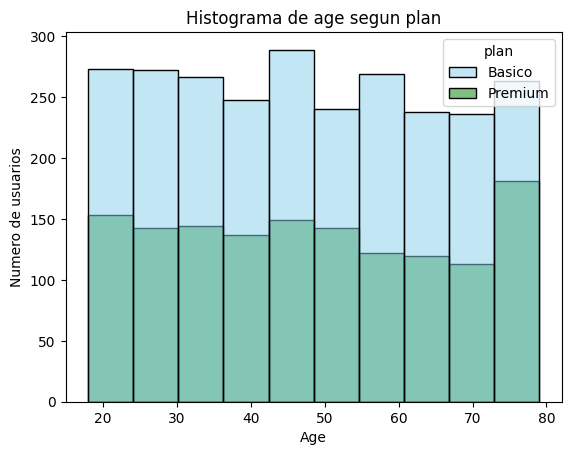

In [48]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, palette=['skyblue','green'], hue='plan')
plt.title('Histograma de age segun plan')
plt.xlabel('Age')
plt.ylabel('Numero de usuarios')
plt.show()

💡Insights: 

- La distribución de usuarios no presenta sesgo prominente, pero tampoco es simetrica ya que se observa un pico en edades entre 40 y 50 años, marcando justo la parte central de la distribución y un pico secundario no tan marcado en los 20s, esto podria indicar dos grupos de usuarios con comportamientos distintos y asi una distribucion bimodal. Hay algo importante que mencionar y es que los clientes de entre 75 y 80 años tienen un pico significativo en los usuarios de plan premium, respecto a todas las demás edades.
Dentro del plan Premium hay un mayor número de usuarios entre 75 y 80 años respecto a todas las demás edades; esto podría representar una oportunidad de negocio, para ofrecer paquetes especiales de llamadas y mensajes para estos usuarios premium que usan en una mayor proporción el servicio.




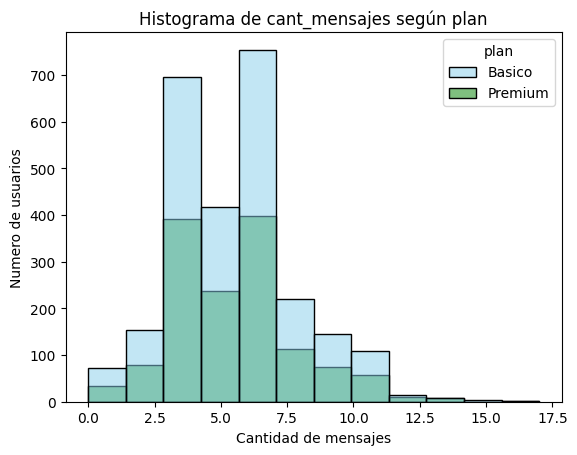

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=12, palette=['skyblue','green'], hue='plan')
plt.title('Histograma de cant_mensajes según plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Numero de usuarios')
plt.show()

💡Insights: 
- La distribución está sesgada a la derecha, se puede observar una cola no muy pronunciada. Esta corresponde a una distribución multimodal considerando que hay dos picos uno entre 2.5 y 5 y el otro entre 5 y 7.5 mensajes. Esto podria sugerir que hay grupos de usuarios con comportamientos distintos y esto podria tomarse como una oportunidad para ofrecer paquetes de mensajes especiales que satisfagan la necesidad de este grupo. La proporción de usuarios entre plan basico y premium es bastante similar, aunque no se observa una diferencia abrupta entre los dos tipos de plan los del plan premium tienden a enviar mas mensajes a partir de los 12 mensajes. Esto puede representar una oportunidad de negocio en la que podria ofrecerse paquetes especiales de mensajes a estos usuarios y asi generar mayor ingresos para el negocio.

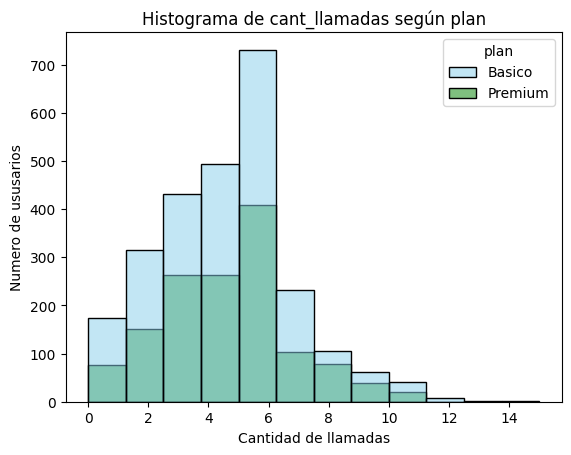

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=12, palette=['skyblue','green'], hue='plan')
plt.title('Histograma de cant_llamadas según plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Numero de ususarios')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha con el pico mas alto en 6 llamadas. A diferencia de los mensajes, en la cantidad de llamadas si se observa una diferencia más marcada entre los usuarios del plan basico y premium, entre mayor cantidad de llamadas realizan mayor es la proporcion de usuarios del plan premium con respecto al basico. Hay valores extremos o outliers, ya que se encuentran alejados de la concentracion de datos. Al analizar el histograma se podria decir que a partir de las seis llamadas una pequena proporcion de los usuarios de ambos tipos de planes realizan llamadas, una gran proporcion de usuarios hacer hasta seis llamadas maximo.

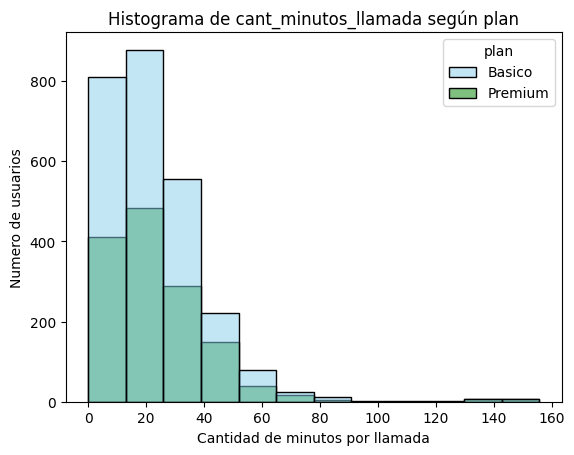

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=12, palette=['skyblue','green'], hue='plan')
plt.title('Histograma de cant_minutos_llamada según plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Numero de usuarios')
plt.show()

💡Insights: 
- La distribucion esta sesgada a la derecha. Se observan outliers bantante notables con entre 120 a 160 minutos por llamada, estos corresponden a usuarios premium. Los usuarios del plan premium y basico suelen estar muy a la par cuando las llamadas tienen menor cantidad de minutos, pero a medida que las llamadas son mas largas, los usuarios del plan premium tienen una mayor proporción respecto a los basicos. El hecho de tener outliers podria sugerir que esto fue un caso raro o un cliente de valor 'whale'.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

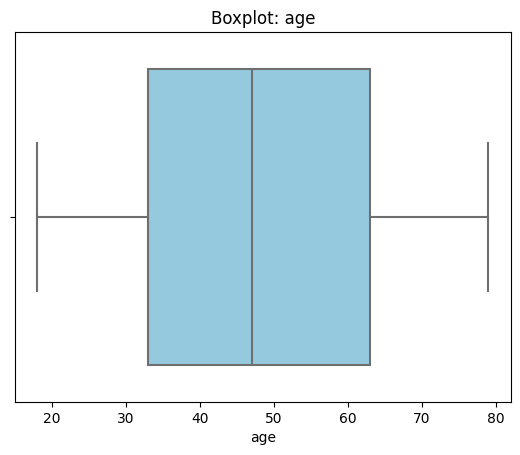

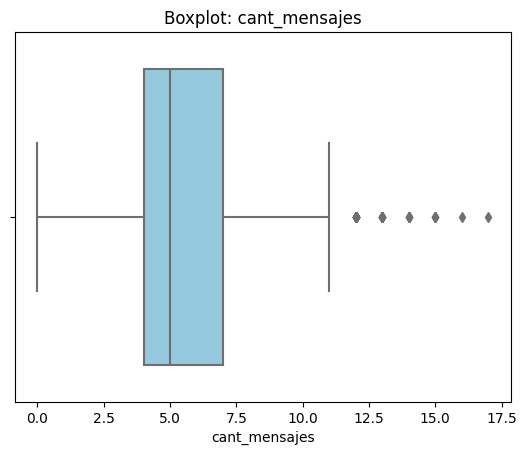

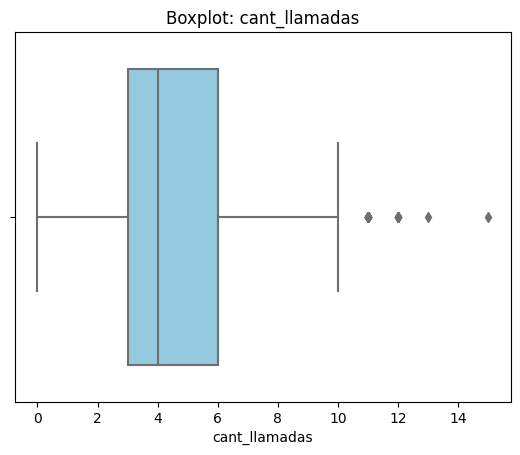

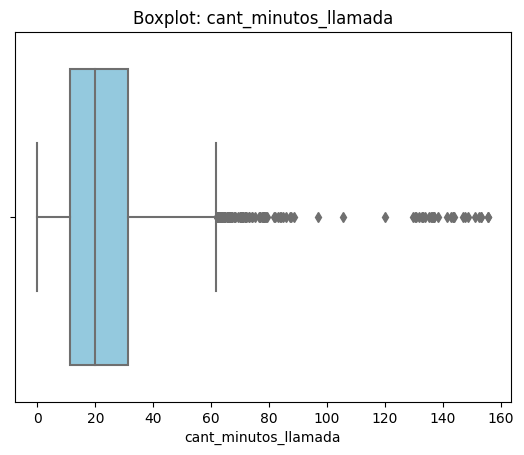

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers. Es una distribucion simetrica.
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [54]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for colim in columnas_limites:
    Q1 = user_profile[colim].quantile(0.25)
    Q3 = user_profile[colim].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR #Calcula limite superior
    lower = Q1 - 1.5*IQR #Calcula limite inferior


In [53]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 


- cant_mensajes: El límite superior IQR es 11.5, el máximo observado es 17. Un usuario con 17 mensajes es inusual pero posible (usuario muy activo), por lo tanto se mantienen los outliers."
- cant_llamadas: El límite superior IQR es 10.5, el máximo observado es 15. Un usuario con 15 llamadas es inusual pero posible (empresa de telecomunaciones), por lo tanto se mantienen los outliers.
- cant_minutos_llamada: El límite superior IQR es 61.86, el máximo observado es 155.69. Un usuario con llamadas de esa duracion es inusual pero posible (llamada con un amigo o familiar que esta lejos), por lo tanto se mantienen los outliers. Esto podria significar una oportunidad de negocio en donde se ofrecen plan con mas minutos incluidos.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [58]:
# Crear columna grupo_uso

def classify_use(row):
    llamada = row['cant_llamadas']
    mensaje = row['cant_mensajes']
 
    if llamada < 5 and mensaje < 5:
            return "Bajo Uso"
        
    # Segmentación de Uso medio (Llamadas y mensajes < 10)
    elif llamada < 10 and mensaje < 10:
            return "Uso medio"
        
    # Segmentación de Alto uso ()
    else: # Llamadas y mensajes > 10
        return "Alto uso"

# aplicar función y ver cambios
user_profile['grupo_uso'] = user_profile.apply(classify_use, axis=1)
user_profile[["cant_llamadas", "cant_mensajes", "grupo_uso"]].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo Uso


In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [60]:
# Crear columna grupo_edad

def classify_age(row):
    edad = row['age']
 
    if edad < 30:
            return "Joven"
        
    # Segmentación de Adulto (Edad < 60)
    elif edad < 60:
            return "Adulto"
        
    # Segmentación de Adulto Mayor (Mayor o igual a 60)
    else: # Age >=60
        return "Adulto Mayor"

# aplicar función y ver cambios
user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)
user_profile[["age", "grupo_edad"]].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [ ]:
# verificar cambios
user_profile.head()

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

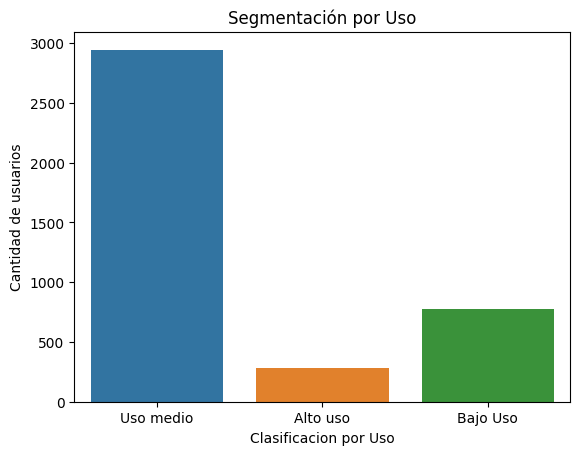

In [63]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Segmentación por Uso')
plt.xlabel('Clasificacion por Uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

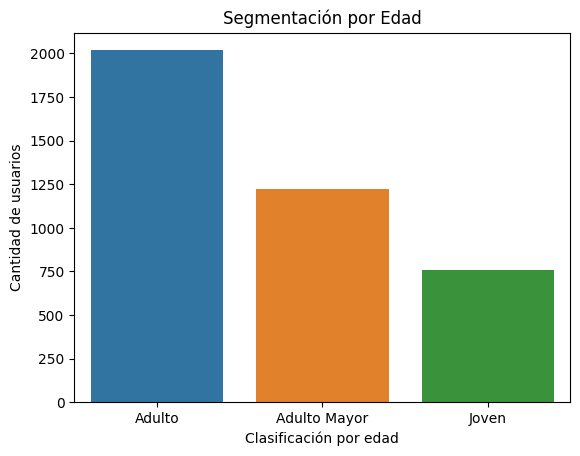

In [65]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Segmentación por Edad')
plt.xlabel('Clasificación por edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante el proceso de exploración y limpieza de datos se identificaron múltiples problemas relacionados con valores nulos, datos inválidos y registros inconsistentes en las tablas Users y Usage.

**Tabla USERS**

`Valores nulos en city`

- La columna city presentaba aproximadamente un 11.7% de valores nulos.
- Debido a que no existen variables adicionales que permitan inferir la ciudad correctamente, se decidió mantener estos valores como nulos, evitando imputaciones arbitrarias que pudieran introducir sesgos en el análisis.

`Valores nulos en churn_date`

- La columna churn_date contenía aproximadamente un 88.35% de valores nulos.
- Tras analizar el significado de esta variable, se concluyó que los valores NaN representan usuarios que continúan activos en la plataforma. Por lo tanto, estos valores no fueron tratados como errores, sino reinterpretados como:

NaN = Usuario activo

`Valores inválidos en age`

- En la columna age se encontraron valores centinela como -999, los cuales representan datos inválidos o faltantes.
- Estos registros fueron reemplazados por valores nulos y posteriormente imputados utilizando la mediana, ya que esta medida reduce el impacto de valores extremos y representa mejor la distribución real de edades.

`Valores inválidos en city`

- En la columna city también se encontraron registros con el valor "?", considerado un dato inválido.
- Estos valores fueron reemplazados por una categoría representativa como "NA" o tratados como valores nulos para mantener consistencia en el análisis.

`Inconsistencias en reg_date`

- La columna reg_date presentaba registros correspondientes a los años 2022, 2023, 2024 y 2026.
- Sin embargo, el conjunto de datos fue recopilado únicamente hasta 2024, por lo que los registros asociados al año 2026 fueron considerados inconsistentes o erróneos.
- Debido a que no existían otras variables que permitieran inferir el año correcto, estos registros fueron marcados como valores nulos (NA). No obstante, las demás columnas asociadas a esos usuarios permanecieron disponibles para el análisis, ya que seguían aportando información útil.

**Tabla USAGE**

`Valores nulos en date`

- La columna date presentaba únicamente un 0.125% de valores nulos.
- Dado que la proporción era mínima y no afectaba significativamente el análisis, estos registros fueron ignorados.

`Valores nulos en duration y length`

Las columnas:

- duration → aproximadamente 55.19% de valores nulos
- length → aproximadamente 44.74% de valores nulos

- presentaban una alta cantidad de datos faltantes. Sin embargo, tras analizar la variable type, se identificó que estos valores nulos son estructurales y completamente esperados según el tipo de registro.

Se observó que:

- duration representa la duración de llamadas telefónicas.
- length representa la longitud de mensajes de texto.

Por lo tanto:

- Cuando el registro corresponde a un mensaje de texto, duration aparece vacío.
- Cuando el registro corresponde a una llamada, length aparece vacío.

- Esto indica que los valores faltantes son del tipo MAR (Missing At Random) y responden a la lógica natural de los datos, por lo que no era apropiado imputarlos artificialmente.


🔍 **Segmentos por Edad**

La distribución de edades no presenta un sesgo prominente, aunque tampoco es completamente simétrica. Se identificó un pico principal entre los 40 y 50 años y un segundo pico menos pronunciado en usuarios de aproximadamente 20 años, lo que sugiere una distribución bimodal y la existencia de distintos grupos de clientes con comportamientos de consumo diferentes.

Los clientes fueron clasificados en tres grupos etarios:

`Jóvenes`: aproximadamente 750 usuarios.

`Adultos`: alrededor de 2000 usuarios, siendo el grupo más representativo dentro de la base de clientes.

`Adultos mayores`: aproximadamente 1250 usuarios.

Los adultos representan el segmento más numeroso de la plataforma y mantienen un comportamiento de uso moderado y constante.

Los adultos mayores tienen una participación especialmente relevante dentro del plan Premium, particularmente entre los 75 y 80 años, donde se observa el pico más alto de usuarios Premium respecto a cualquier otro rango de edad.

Este comportamiento sugiere que los adultos mayores utilizan con mayor frecuencia servicios tradicionales de comunicación como llamadas y mensajes, posiblemente debido a hábitos de consumo distintos respecto a usuarios jóvenes.


📊 **Segmentos por Nivel de Uso**

Los usuarios fueron clasificados según intensidad de consumo en:

`Uso Bajo`: entre 700 y 800 usuarios.

`Uso Medio`: aproximadamente 3000 usuarios, representando la mayor parte de la base de clientes.

`Uso Alto`: menos de 500 usuarios.

La distribución de mensajes presenta un sesgo hacia la derecha y características multimodales, con picos entre 2.5–5 y 5–7.5 mensajes, lo que indica la presencia de diferentes perfiles de usuarios.

Aunque la proporción de usuarios Básicos y Premium es relativamente similar en niveles bajos de mensajería, a partir de aproximadamente 12 mensajes los usuarios Premium comienzan a predominar.

En la cantidad de llamadas sí se observa una diferencia más marcada entre planes: a medida que aumenta el número de llamadas realizadas, incrementa también la proporción de usuarios Premium.

La distribución de minutos por llamada también presenta un sesgo hacia la derecha y evidencia outliers importantes entre 120 y 160 minutos por llamada, principalmente asociados a usuarios Premium.

Estos valores extremos representan usuarios altamente activos o clientes de alto valor (“whales”), cuyos patrones de uso podrían ser estratégicamente importantes para la empresa


➡️ Esto sugiere que ConnectaTel posee una base de clientes diversa, con distintos patrones de consumo según edad y nivel de uso. Los adultos y adultos mayores representan segmentos clave para el negocio, especialmente dentro del plan Premium, mientras que los usuarios de alto consumo constituyen una pequeña proporción de clientes, pero con alto potencial de rentabilidad. Además, el comportamiento multimodal observado en mensajes y edades evidencia la existencia de diferentes perfiles de usuarios que podrían beneficiarse de ofertas más personalizadas.


💡 **Recomendaciones**
- Diseñar planes específicos para adultos mayores, incluyendo más minutos y mensajes, considerando que este grupo presenta una alta participación dentro del plan Premium.
- Crear paquetes diferenciados según intensidad de uso, especialmente para usuarios de alto consumo y clientes con llamadas prolongadas.
- Implementar planes Premium especializados para usuarios con necesidades de comunicación intensiva, incluyendo llamadas ilimitadas o paquetes de mensajería ampliados.
- Desarrollar campañas de fidelización orientadas a usuarios Premium y clientes de alto valor, ya que representan una importante oportunidad de generación de ingresos.
- Crear ofertas específicas para jóvenes, enfocadas en mensajería y beneficios digitales, considerando que este grupo presenta patrones de uso distintos respecto a adultos y adultos mayores.
- Mantener monitoreo sobre usuarios extremos u outliers, ya que podrían representar tanto oportunidades comerciales como comportamientos atípicos relevantes para el negocio.

Link a repositorio público del proyecto: `LINK a tu repo aquí`

## ✅ Paso 8: Publicación en GitHub


1. Descarga tu notebook de Jupyter

Ve a File → Download as → Notebook (.ipynb) para guardar una copia en tu computadora.

2. Crea tu repositorio en GitHub

Ve a github.com e inicia sesión.
Haz clic en New repository.
Nómbralo algo como connectatel-analysis.
Selecciona Public y marca Add a README file.
Haz clic en Create repository.
3. Sube tu notebook

Dentro de tu repositorio, haz clic en Add file → Upload files.
Arrastra tu archivo .ipynb.
Escribe un mensaje de commit como: feat: add ConnectaTel analysis notebook
Haz clic en Commit changes.
4. Edita tu README

Haz clic en el ícono de lápiz del README y agrega:

Descripción del proyecto ConnectaTel
Qué contiene el notebook
Cómo reproducir el análisis